Applying SMOTE geometric interpolation
Training sequential trees (XGBoost)
Pipeline training completed successfully

--- Classification Report (20% Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.88      0.75        98

    accuracy                           1.00     56962
   macro avg       0.83      0.94      0.88     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC Score: 0.8774


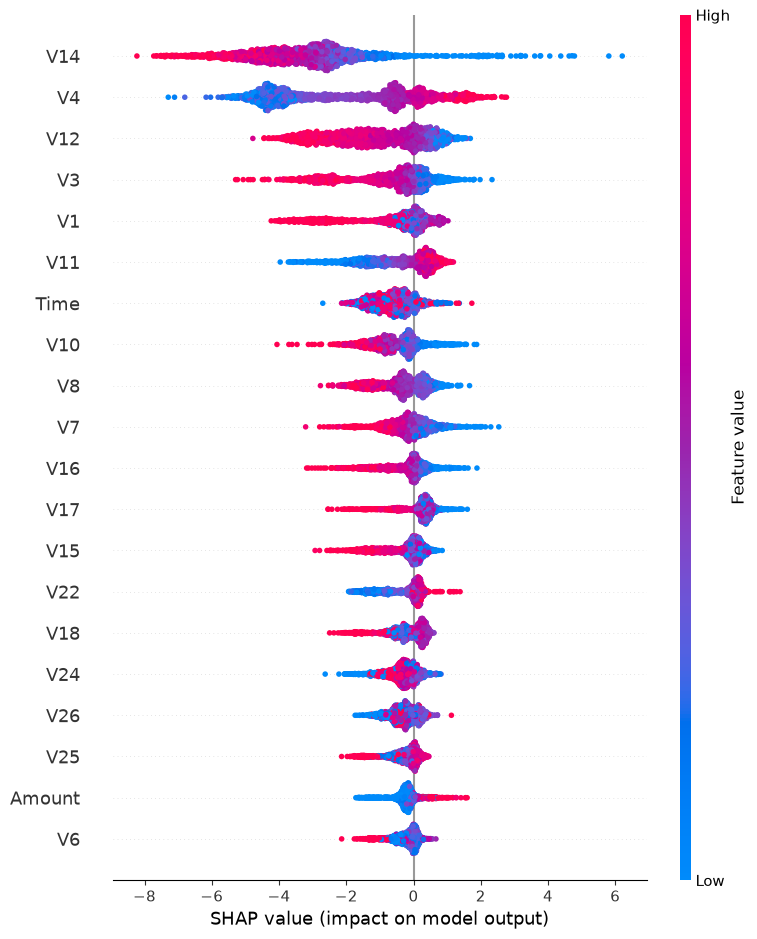

['fraud_detector_model.pkl']

In [2]:
import pandas as pd
import joblib
import shap
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc

class FraudDetectionModel :
    def __init__(self, random_state=42) :
        self.random_state = random_state
        self.model = XGBClassifier(random_state=random_state, eval_metric='logloss')
        self.smote = SMOTE(random_state=random_state)

    def fit_resample(self, X_train, y_train) :
        """Applies SMOTE and trains the XGBoost Model"""
        print("Applying SMOTE geometric interpolation")
        X_train_res , y_train_res = self.smote.fit_resample(X_train, y_train)

        print("Training sequential trees (XGBoost)")
        self.model.fit(X_train_res, y_train_res)
        print("Pipeline training completed successfully")

    def predict_proba(self, X_test) :
        """Returns raw probabilities of fraud transactions (Class 1)"""
        return self.model.predict_proba(X_test)[:, 1]

    def evaluate(self, X_test, y_test) :
        """Evaluates model using PR-AUC and a classification report."""
        y_pred_proba = self.predict_proba(X_test)

        custom_threshold = 0.20
        y_pred = (y_pred_proba >= custom_threshold).astype(int)

        print(f"\n--- Classification Report ({int(custom_threshold*100)}% Threshold) ---")
        print(classification_report(y_test, y_pred))

        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc_score = auc(recall, precision)

        print(f"PR-AUC Score: {pr_auc_score:.4f}")
        return pr_auc_score


df = pd.read_csv("creditcard.csv")
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = FraudDetectionModel()

pipeline.fit_resample(X_train, y_train)

pipeline.evaluate(X_test, y_test)

shap.initjs()

explainer = shap.TreeExplainer(pipeline.model)

X_test_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values, X_test_sample)

joblib.dump(pipeline, 'fraud_detector_model.pkl')

In [1]:
import sklearn
import xgboost
import pandas

print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"Pandas version: {pandas.__version__}")

Scikit-Learn version: 1.9.0
XGBoost version: 3.3.0
Pandas version: 3.0.3
